# Контрольная работа №1
## Максимов Павел Александрович


## Задание №1


### Пункт 1: Загрузка датасета


In [5]:
!conda install -y pandas numpy matplotlib scikit-learn

2 channel Terms of Service accepted
Channels:
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.11.0

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

df = pd.read_csv('Salary.csv')
df.head()


Matplotlib is building the font cache; this may take a moment.


,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


### Пункт 2: Построение гистограмм распределения зарплат и опыта работы


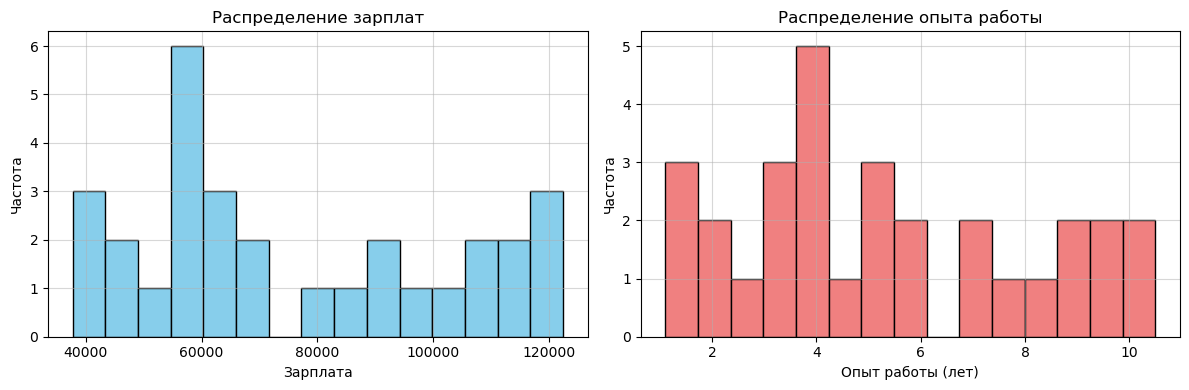

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df['Salary'], bins=15, color='skyblue', edgecolor='black')
ax1.set_title('Распределение зарплат')
ax1.set_xlabel('Зарплата')
ax1.set_ylabel('Частота')
ax1.grid(True, alpha=0.5)

ax2.hist(df['YearsExperience'], bins=15, color='lightcoral', edgecolor='black')
ax2.set_title('Распределение опыта работы')
ax2.set_xlabel('Опыт работы (лет)')
ax2.set_ylabel('Частота')
ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

**Комментарий к гистограммам:**

По гистограмме зарплат видно, что большинство значений сосредоточены в нижней части диапазона (примерно от 40 000 до ~70 000), а высокие зарплаты встречаются реже, что довольно типично для распределения зарплаты.

Гистограмма опыта работы показывает, что в выборке находится больше людей с меньшим опытом работы (преимущественно до 5-6 лет).


### Пункт 3: Точечный график зависимости зарплаты от опыта работы


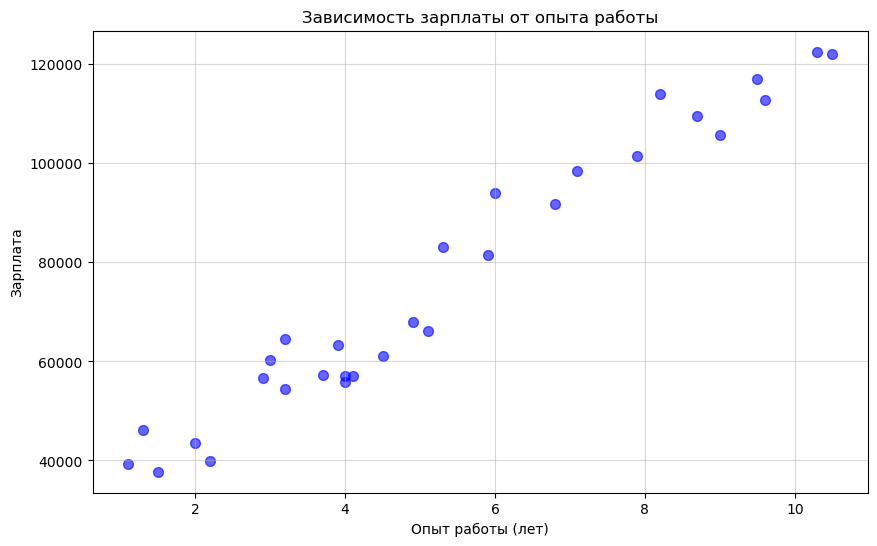

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(df['YearsExperience'], df['Salary'], alpha=0.6, color='blue', s=50)
plt.title('Зависимость зарплаты от опыта работы')
plt.xlabel('Опыт работы (лет)')
plt.ylabel('Зарплата')
plt.grid(True, alpha=0.5)
plt.show()

**Комментарий к точечному графику:**

На графике можно распознать линейную зависимость между опытом работы и зарплатой (очевидно положительную).


### Пункт 4: Отскалирование данных зарплат


In [9]:
scaler = MinMaxScaler()
df['Scalared_Salary'] = scaler.fit_transform(df[['Salary']])
df[['Salary', 'Scalared_Salary']].head(10)


,Salary,Scalared_Salary
0,39343,0.019041
1,46205,0.100094
2,37731,0.000000
3,43525,0.068438
4,39891,0.025514
5,56642,0.223376
6,60150,0.264812
7,54445,0.197425
8,64445,0.315545
9,57189,0.229837


### Пункт 5: Инициализация, обучение модели линейной регрессии и метрики


In [10]:
X = df[['YearsExperience']]
y = df['Scalared_Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Метрики на обучающей выборке:")
print(f"MSE: {train_mse:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"MAE: {train_mae:.6f}")
print(f"R²: {train_r2:.6f}")

print("\nМетрики на тестовой выборке:")
print(f"MSE: {test_mse:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"MAE: {test_mae:.6f}")
print(f"R²: {test_r2:.6f}")

print(f"\nКоэффициенты модели:")
print(f"Коэффициент (a): {model.coef_[0]:.6f}")
print(f"Смещение (b): {model.intercept_:.6f}")

Метрики на обучающей выборке:
MSE: 0.003781
RMSE: 0.061493
MAE: 0.049859
R²: 0.964540

Метрики на тестовой выборке:
MSE: 0.006952
RMSE: 0.083381
MAE: 0.074255
R²: 0.902446

Коэффициенты модели:
Коэффициент (a): 0.111314
Смещение (b): -0.146579


### Пункт 6: Построение графика линейной регрессии на точечном графике


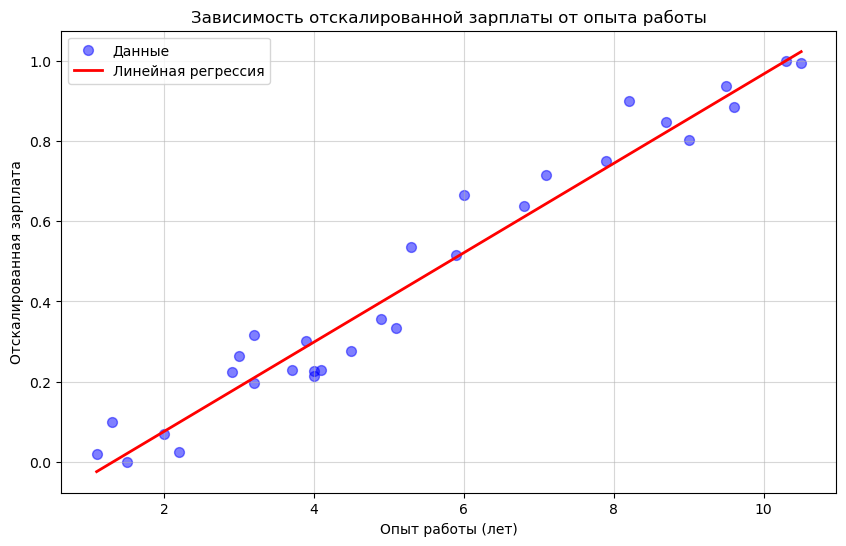

In [13]:
x_line = np.linspace(np.min(df['YearsExperience']), np.max(df['YearsExperience']), 100)
x_line_df = pd.DataFrame(x_line, columns=['YearsExperience'])
y_line = model.predict(x_line_df)

plt.figure(figsize=(10, 6))
plt.scatter(df['YearsExperience'], df['Scalared_Salary'], alpha=0.5, color='blue', s=50, label='Данные')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Линейная регрессия')
plt.title('Зависимость отскалированной зарплаты от опыта работы')
plt.xlabel('Опыт работы (лет)')
plt.ylabel('Отскалированная зарплата')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


## Задание №2


### Пункт 1: Загрузка датасета


In [14]:
df_insurance = pd.read_csv('Insurance.csv')
df_insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Пункт 2: Анализ датасета

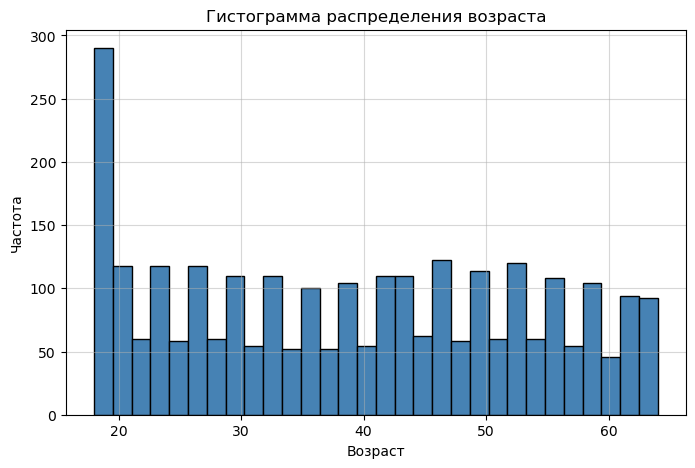

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_insurance['age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Гистограмма распределения возраста')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.grid(True, alpha=0.5)
plt.show()

In [16]:
print("Количество мужчин:", (df_insurance['sex'] == 'male').sum())
print("Количество женщин:", (df_insurance['sex'] == 'female').sum())

print(f"\nСредний индекс массы тела (BMI): {df_insurance['bmi'].mean():.2f}")

print(f"\nКоличество курящих: {(df_insurance['smoker'] == 'yes').sum()}")
print(f"Количество не курящих: {(df_insurance['smoker'] == 'no').sum()}")

print(f"\nКоличество людей с детьми: {(df_insurance['children'] > 0).sum()}")
print(f"Количество людей без детей: {(df_insurance['children'] == 0).sum()}")

print("\nКоличество людей по регионам:")
print(df_insurance['region'].value_counts())

print("\nСредняя выплата для мужчин:", df_insurance[df_insurance['sex'] == 'male']['charges'].mean())
print("Средняя выплата для женщин:", df_insurance[df_insurance['sex'] == 'female']['charges'].mean())


Количество мужчин: 1406
Количество женщин: 1366

Средний индекс массы тела (BMI): 30.70

Количество курящих: 564
Количество не курящих: 2208

Количество людей с детьми: 1586
Количество людей без детей: 1186

Количество людей по регионам:
region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64

Средняя выплата для мужчин: 14013.872721266001
Средняя выплата для женщин: 12486.83197685066


**Вывод о сбалансированности набора данных:**

На основе проведенного анализа можно сделать следующие выводы:
- По полу: данные достаточно сбалансированы, количество мужчин и женщин примерно одинаковое
- По курению: наблюдается дисбаланс - некурящих значительно больше, чем курящих
- По наличию детей: наблюдается небольшой перевес в сторону людей с детьми
- По регионам: данные распределены относительно равномерно
- По возрасту: очень много людей возрастом до 20 лет, после 20 распределение равномерное
- По выплате: для мужчин средняя выплата чуть больше

В целом, набор данных можно считать относительно сбалансированным, однако есть перевес в сторону некурящих людей и людей возрастом до 20 лет


### Пункт 3: Сравнение людей с максимальной и минимальной выплатой


In [24]:
max_charge_idx = df_insurance['charges'].idxmax()
min_charge_idx = df_insurance['charges'].idxmin()

print("Человек с максимальной выплатой:")
print(df_insurance.loc[max_charge_idx])
print("\nЧеловек с минимальной выплатой:")
print(df_insurance.loc[min_charge_idx])

print("\nСравнение средних показателей:")

print("\nСредние показатели для всей группы:")
print(f"Средний возраст: {df_insurance['age'].mean():.2f}")
print(f"Средний BMI: {df_insurance['bmi'].mean():.2f}")
print(f"Среднее количество детей: {df_insurance['children'].mean():.2f}")
print(f"Средняя выплата: {df_insurance['charges'].mean():.2f}")

print("\nПоказатели человека с максимальной выплатой:")
print(f"Возраст: {df_insurance.loc[max_charge_idx, 'age']}")
print(f"BMI: {df_insurance.loc[max_charge_idx, 'bmi']:.2f}")
print(f"Количество детей: {df_insurance.loc[max_charge_idx, 'children']}")
print(f"Выплата: {df_insurance.loc[max_charge_idx, 'charges']:.2f}")

print("\nПоказатели человека с минимальной выплатой:")
print(f"Возраст: {df_insurance.loc[min_charge_idx, 'age']}")
print(f"BMI: {df_insurance.loc[min_charge_idx, 'bmi']:.2f}")
print(f"Количество детей: {df_insurance.loc[min_charge_idx, 'children']}")
print(f"Выплата: {df_insurance.loc[min_charge_idx, 'charges']:.2f}")

Человек с максимальной выплатой:
age                  54
sex              female
bmi               47.41
children              0
smoker              yes
region        southeast
charges     63770.42801
Name: 543, dtype: object

Человек с минимальной выплатой:
age                18
sex              male
bmi             23.21
children            0
smoker             no
region      southeast
charges     1121.8739
Name: 940, dtype: object

Сравнение средних показателей:

Средние показатели для всей группы:
Средний возраст: 39.11
Средний BMI: 30.70
Среднее количество детей: 1.10
Средняя выплата: 13261.37

Показатели человека с максимальной выплатой:
Возраст: 54
BMI: 47.41
Количество детей: 0
Выплата: 63770.43

Показатели человека с минимальной выплатой:
Возраст: 18
BMI: 23.21
Количество детей: 0
Выплата: 1121.87


**Комментарий к результатам:**

Сравнение показывает существенные различия между людьми с максимальной и минимальной выплатой. Человек с максимальной выплатой, более возрастной с более высоким BMI и курящий, что существенно влияет на размер страховой выплаты. Человек с минимальной выплатой, наоборот, имеет низкие показатели риска (моложе, низкий BMI, некурящий). Что соответствует логике страховых выплат - чем выше факторы риска, тем выше выплата.


### Пункт 4: Предобработка данных (перевод категориальных признаков в вещественные)


In [18]:
df_processed = df_insurance.copy()

df_processed['sex'] = df_processed['sex'].map({'male': 0, 'female': 1})

df_processed['smoker'] = df_processed['smoker'].map({'yes': 0, 'no': 1})

unique_regions = df_processed['region'].unique()
region_mapping = {region: i+1 for i, region in enumerate(unique_regions)}
df_processed['region'] = df_processed['region'].map(region_mapping)

print("Первые 10 строк после предобработки:")
print(df_processed.head(10))
print("\nТипы данных:")
print(df_processed.dtypes)

Первые 10 строк после предобработки:
   age  sex     bmi  children  smoker  region      charges
0   19    1  27.900         0       0       1  16884.92400
1   18    0  33.770         1       1       2   1725.55230
2   28    0  33.000         3       1       2   4449.46200
3   33    0  22.705         0       1       3  21984.47061
4   32    0  28.880         0       1       3   3866.85520
5   31    1  25.740         0       1       2   3756.62160
6   46    1  33.440         1       1       2   8240.58960
7   37    1  27.740         3       1       3   7281.50560
8   37    0  29.830         2       1       4   6406.41070
9   60    1  25.840         0       1       3  28923.13692

Типы данных:
age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object


### Пункт 5: Инициализация, обучение модели линейной регрессии и измерение метрик

In [19]:
X = df_processed[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df_processed['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_insurance = LinearRegression()

model_insurance.fit(X_train, y_train)

y_train_pred = model_insurance.predict(X_train)
y_test_pred = model_insurance.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Метрики на обучающей выборке:")
print(f"MSE: {train_mse:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"MAE: {train_mae:.2f}")
print(f"R²: {train_r2:.4f}")

print("\nМетрики на тестовой выборке:")
print(f"MSE: {test_mse:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"MAE: {test_mae:.2f}")
print(f"R²: {test_r2:.4f}")

print(f"\nКоэффициенты модели:")
for i, feature in enumerate(X.columns):
    print(f"{feature}: {model_insurance.coef_[i]:.2f}")
print(f"Смещение (intercept): {model_insurance.intercept_:.2f}")

Метрики на обучающей выборке:
MSE: 36024723.55
RMSE: 6002.06
MAE: 4136.38
R²: 0.7534

Метрики на тестовой выборке:
MSE: 39922479.35
RMSE: 6318.42
MAE: 4167.30
R²: 0.7399

Коэффициенты модели:
age: 255.05
sex: 69.84
bmi: 319.32
children: 458.67
smoker: -23841.41
region: 388.86
Смещение (intercept): 10885.27


**Комментарий к результатам:**

Модель показывает достаточно хорошие результаты. Метрики на обучающей и тестовой выборках близки, что говорит об отсутствии переобучения. 

Анализируя коэффициенты модели, можно увидеть, какие признаки наиболее важны для предсказания выплаты, например, признак курения имеет очень высокий коэффициент, так как оно значительно увеличивает страховые риски.


### Пункт 6*: Отбор признаков


Корреляция признаков с целевой переменной:
charges     1.000000
age         0.298624
bmi         0.199846
children    0.066442
region      0.013530
sex        -0.062837
smoker     -0.788783
Name: charges, dtype: float64


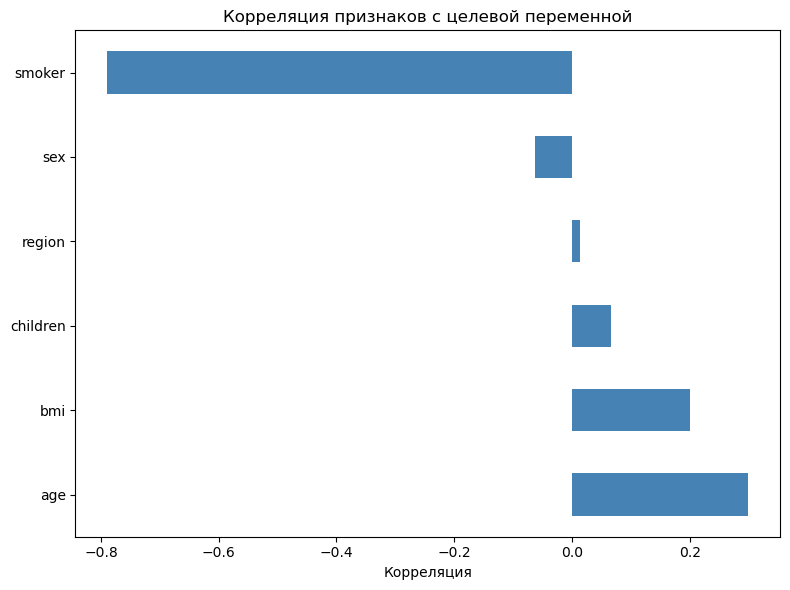

In [21]:
correlation = df_processed.corr()['charges'].sort_values(ascending=False)
print("Корреляция признаков с целевой переменной:")
print(correlation)

plt.figure(figsize=(8, 6))
correlation_without_target = correlation.drop('charges')
correlation_without_target.plot(kind='barh', color='steelblue')
plt.title('Корреляция признаков с целевой переменной')
plt.xlabel('Корреляция')
plt.tight_layout()
plt.show()

**Обоснование отбора признаков:**

На основе анализа корреляций видно, что некоторые признаки имеют более сильную связь с целевой переменной, так признак курения обычно имеет очень высокую корреляцию с выплатами, так как курение является одним из основных факторов риска. Также можно заметить, что возраст и BMI тоже важны. Регион может иметь меньшую важность, давайте попробуем убрать его и посмотрим, как это повлияет на метрики модели.


In [27]:
X_selected = df_processed[['age', 'sex', 'bmi', 'children', 'smoker']]
y = df_processed['charges']

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model_insurance_selected = LinearRegression()

model_insurance_selected.fit(X_train_sel, y_train_sel)

y_train_pred_sel = model_insurance_selected.predict(X_train_sel)
y_test_pred_sel = model_insurance_selected.predict(X_test_sel)

train_mse_sel = mean_squared_error(y_train_sel, y_train_pred_sel)
train_rmse_sel = np.sqrt(train_mse_sel)
train_mae_sel = mean_absolute_error(y_train_sel, y_train_pred_sel)
train_r2_sel = r2_score(y_train_sel, y_train_pred_sel)

test_mse_sel = mean_squared_error(y_test_sel, y_test_pred_sel)
test_rmse_sel = np.sqrt(test_mse_sel)
test_mae_sel = mean_absolute_error(y_test_sel, y_test_pred_sel)
test_r2_sel = r2_score(y_test_sel, y_test_pred_sel)

print("Метрики модели С ОТБОРОМ ПРИЗНАКОВ:")
print("\nНа обучающей выборке:")
print(f"MSE: {train_mse_sel:.2f}")
print(f"RMSE: {train_rmse_sel:.2f}")
print(f"MAE: {train_mae_sel:.2f}")
print(f"R²: {train_r2_sel:.4f}")

print("\nНа тестовой выборке:")
print(f"MSE: {test_mse_sel:.2f}")
print(f"RMSE: {test_rmse_sel:.2f}")
print(f"MAE: {test_mae_sel:.2f}")
print(f"R²: {test_r2_sel:.4f}")

print("\nСРАВНЕНИЕ С ПРЕДЫДУЩЕЙ МОДЕЛЬЮ:")

print(f"\nR² на тесте (все признаки): {test_r2:.4f}")
print(f"R² на тесте (без region): {test_r2_sel:.4f}")
print(f"Изменение R²: {test_r2_sel - test_r2:.4f}")
print(f"\nRMSE на тесте (все признаки): {test_rmse:.2f}")
print(f"RMSE на тесте (без region): {test_rmse_sel:.2f}")
print(f"Изменение RMSE: {test_rmse_sel - test_rmse:.2f}")

Метрики модели С ОТБОРОМ ПРИЗНАКОВ:

На обучающей выборке:
MSE: 36204171.69
RMSE: 6016.99
MAE: 4140.30
R²: 0.7522

На тестовой выборке:
MSE: 40093450.23
RMSE: 6331.94
MAE: 4169.89
R²: 0.7388

СРАВНЕНИЕ С ПРЕДЫДУЩЕЙ МОДЕЛЬЮ:

R² на тесте (все признаки): 0.7399
R² на тесте (без region): 0.7388
Изменение R²: -0.0011

RMSE на тесте (все признаки): 6318.42
RMSE на тесте (без region): 6331.94
Изменение RMSE: 13.52


**Комментарий к результатам отбора признаков:**

После удаления признака региона метрики модели практически не изменились или изменились незначительно. Это подтверждает, что этот признак не является важным для предсказания страховых выплат в данной модели. 
